# Task B — Severity Prediction: Complete Pipeline
## FAERS Drug Interactions Risk Project

Este notebook ejecuta **todo el pipeline de Task B** de principio a fin:

1. Verifica dependencias y genera las reglas filtradas de Task A si no existen
2. Ingesta los datos crudos del ZIP de FAERS
3. Construye la feature matrix de 25 columnas
4. Entrena y evalúa 3 clasificadores: Logistic Regression, Random Forest, Gradient Boosting (HGBC)
5. Optimización de umbral de clasificación por F1 (severe) en validation set
6. Genera plots de evaluación embebidos en el notebook

**Correr desde la raíz del proyecto** (`DrugInteractionsRisks/`)

In [1]:
%matplotlib inline
import os, sys, subprocess, glob, warnings, time
warnings.filterwarnings('ignore')

# ── Ensure we are at project root ─────────────────────────────────────────────
notebook_dir = os.path.abspath('')
if not os.path.isdir(os.path.join(notebook_dir, 'taskA')):
    parent = os.path.dirname(notebook_dir)
    if os.path.isdir(os.path.join(parent, 'taskA')):
        os.chdir(parent)

print('Working directory:', os.getcwd())
assert os.path.isdir('taskA'), 'ERROR: Run this notebook from the DrugInteractionsRisks/ root folder!'
print('Project root confirmed ✓')

Working directory: /home/controller/DrugInteractionsRisks
Project root confirmed ✓


In [2]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, f1_score,
    precision_recall_curve, average_precision_score,
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_FRAC     = 0.10   # fraction of training set for threshold tuning

# ── Paths ─────────────────────────────────────────────────────────────────────
ZIP_PATH        = os.path.join('taskB', '9 json files - no tocar.zip')
CONSOLIDATED    = 'consolidated_data.parquet'
ENCODED_PARQUET = os.path.join('taskA', 'active_substances_encoded.parquet')
RULES_RAW_DIR   = os.path.join('taskA', 'association_rules')
FILTERED_DIR    = os.path.join('taskA', 'filtered_association_rules')
FILTERED_GLOB   = os.path.join(FILTERED_DIR, '*.csv')
FEATURES_PATH   = os.path.join('taskB', 'task_b_features.parquet')
OUTPUT_DIR      = os.path.join('taskB', 'TaskBPlots')
EVAL_CSV        = os.path.join('taskB', 'task_b_evaluation.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Paths configured ✓')

Paths configured ✓


---
## FASE 0 — Dependency Check
Verifica qué ficheros existen y cuáles hay que generar.

In [3]:
def check(label, path):
    exists = os.path.exists(path)
    icon   = '✓' if exists else '✗ MISSING'
    print(f'  {icon:<10} {label:<45} {path}')
    return exists

print('=== DEPENDENCY CHECK ===')
has_encoded  = check('Encoded parquet (Task A)',  ENCODED_PARQUET)
has_filtered = check('Filtered rules dir',         FILTERED_DIR)
has_consol   = check('consolidated_data.parquet',  CONSOLIDATED)
has_zip      = check('FAERS ZIP file',             ZIP_PATH)
has_features = check('task_b_features.parquet',    FEATURES_PATH)

print()
if not has_encoded:
    raise FileNotFoundError(
        'CRITICAL: active_substances_encoded.parquet missing. '
        'This file must come from the git repo — it cannot be regenerated without consolidated_data.parquet.'
    )
if not has_zip and not has_consol:
    raise FileNotFoundError(
        f'CRITICAL: Need either {ZIP_PATH} or {CONSOLIDATED}. '
        'Place the ZIP at the path above.'
    )
print('Minimum requirements satisfied ✓')

=== DEPENDENCY CHECK ===
  ✓          Encoded parquet (Task A)                      taskA/active_substances_encoded.parquet
  ✓          Filtered rules dir                            taskA/filtered_association_rules
  ✓          consolidated_data.parquet                     consolidated_data.parquet
  ✓          FAERS ZIP file                                taskB/9 json files - no tocar.zip
  ✓          task_b_features.parquet                       taskB/task_b_features.parquet

Minimum requirements satisfied ✓


---
## FASE 1 — Generar Filtered Association Rules (Task A → Task B bridge)

Las reglas filtradas de Task A son necesarias para las 4 features de interacción en Task B.  
Los encoded parquets YA están en el repo, así que esto corre **sin necesitar el ZIP**.

In [4]:
filtered_files = glob.glob(FILTERED_GLOB)

if filtered_files:
    print(f'Filtered rules already exist ({len(filtered_files)} file(s)):')
    for f in filtered_files:
        df_tmp = pd.read_csv(f)
        print(f'  {os.path.basename(f)} — {len(df_tmp)} rules, max_lift={df_tmp["lift"].max():.2f}')
else:
    print('Filtered rules not found. Generating from encoded parquet...')

    # ── Step 1: Apriori on existing encoded parquet ────────────────────────────
    apriori_cmd = [
        sys.executable, 'taskA/4A_APriori.py',
        '--file_path', ENCODED_PARQUET,
        '--min_support', '0.0025',
    ]
    print('\nRunning Apriori...')
    r1 = subprocess.run(apriori_cmd, capture_output=True, text=True)
    if r1.returncode != 0:
        print('STDERR:', r1.stderr)
        raise RuntimeError('4A_APriori.py failed — see STDERR above')
    print(r1.stdout[-2000:])   # last 2000 chars to avoid flooding

    # ── Step 2: Filter ────────────────────────────────────────────────────────
    apriori_csv = os.path.join(
        RULES_RAW_DIR, 'association_rules_APRIORI_active_substances_0_0025.csv'
    )
    if not os.path.exists(apriori_csv):
        raise FileNotFoundError(
            f'Expected Apriori CSV not found at {apriori_csv}. '
            'Check 4A_APriori.py output above.'
        )

    filter_cmd = [
        sys.executable, 'taskA/6A_FilterTrueInteractions.py',
        '--input', apriori_csv,
    ]
    print('\nRunning filter...')
    r2 = subprocess.run(filter_cmd, capture_output=True, text=True)
    if r2.returncode != 0:
        print('STDERR:', r2.stderr)
        raise RuntimeError('6A_FilterTrueInteractions.py failed — see STDERR above')
    print(r2.stdout)

    filtered_files = glob.glob(FILTERED_GLOB)
    if not filtered_files:
        raise RuntimeError(
            'Filtering ran but no CSVs found in taskA/filtered_association_rules/. '
            'Possibly no rules survived the filter — check noise_terms in 6A script.'
        )

print(f'\nFiltered rules ready: {len(filtered_files)} file(s) ✓')

Filtered rules already exist (1 file(s)):
  filtered_association_rules_APRIORI_active_substances_0_0025.csv — 13 rules, max_lift=223.45

Filtered rules ready: 1 file(s) ✓


---
## FASE 2 — Data Ingestion

Lee el ZIP con los 9 JSON de FAERS y genera `consolidated_data.parquet`.  
Si el parquet ya existe, se salta este paso.

In [5]:
if os.path.exists(CONSOLIDATED):
    _tmp = pd.read_parquet(CONSOLIDATED)
    print(f'consolidated_data.parquet already exists: {len(_tmp):,} rows × {len(_tmp.columns)} columns ✓')
    del _tmp
else:
    print(f'Running ingestion from {ZIP_PATH}...')
    t0 = time.time()
    r = subprocess.run(
        [sys.executable, 'taskB/1B_dataIngestion.py', ZIP_PATH],
        capture_output=True, text=True
    )
    print(r.stdout)
    if r.returncode != 0:
        print('STDERR:', r.stderr)
        raise RuntimeError('1B_dataIngestion.py failed')
    if not os.path.exists(CONSOLIDATED):
        raise FileNotFoundError('Ingestion ran but consolidated_data.parquet was not created')
    print(f'Ingestion done in {time.time()-t0:.1f}s ✓')

consolidated_data.parquet already exists: 108,000 rows × 40 columns ✓


---
## FASE 3 — Feature Engineering

Construye la feature matrix a partir de `consolidated_data.parquet` y las reglas filtradas.  
Si `task_b_features.parquet` ya existe, se salta.

In [6]:
if os.path.exists(FEATURES_PATH):
    df_feat = pd.read_parquet(FEATURES_PATH)
    print(f'task_b_features.parquet already exists: {df_feat.shape} ✓')
else:
    print('Running feature engineering (2B_preprocessing.py)...')
    t0 = time.time()
    r = subprocess.run(
        [sys.executable, 'taskB/2B_preprocessing.py'],
        capture_output=True, text=True
    )
    print(r.stdout)
    if r.returncode != 0:
        print('STDERR:', r.stderr)
        raise RuntimeError('2B_preprocessing.py failed')
    if not os.path.exists(FEATURES_PATH):
        raise FileNotFoundError('Preprocessing ran but task_b_features.parquet was not created')
    df_feat = pd.read_parquet(FEATURES_PATH)
    print(f'Feature engineering done in {time.time()-t0:.1f}s ✓')

print(f'\nFeature matrix: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} columns')
print('Columns:', list(df_feat.columns))

task_b_features.parquet already exists: (108000, 25) ✓

Feature matrix: 108,000 rows × 25 columns
Columns: ['patientonsetage', 'is_male', 'is_female', 'sex_unknown', 'is_severe_outcome', 'num_drugs_taken', 'takes_tirzepatide', 'takes_dupilumab', 'takes_prednisone', 'takes_methotrexate', 'takes_omalizumab', 'takes_adalimumab', 'takes_acetaminophen', 'takes_infliximab_dyyb', 'takes_infliximab', 'takes_rituximab', 'takes_leuprolide_acetate', 'takes_tocilizumab', 'takes_vedolizumab', 'takes_amlodipine_besylate', 'takes_cetirizine_hydrochloride', 'has_drug_drug_interaction', 'has_drug_reaction_rule', 'num_matching_rules', 'max_interaction_lift']


---
## FASE 4 — Exploratory Analysis of Feature Matrix

=== CLASS BALANCE ===
  Non-Severe (0):  79,317  (73.4%)
  Severe     (1):  28,683  (26.6%)
  Total:          108,000


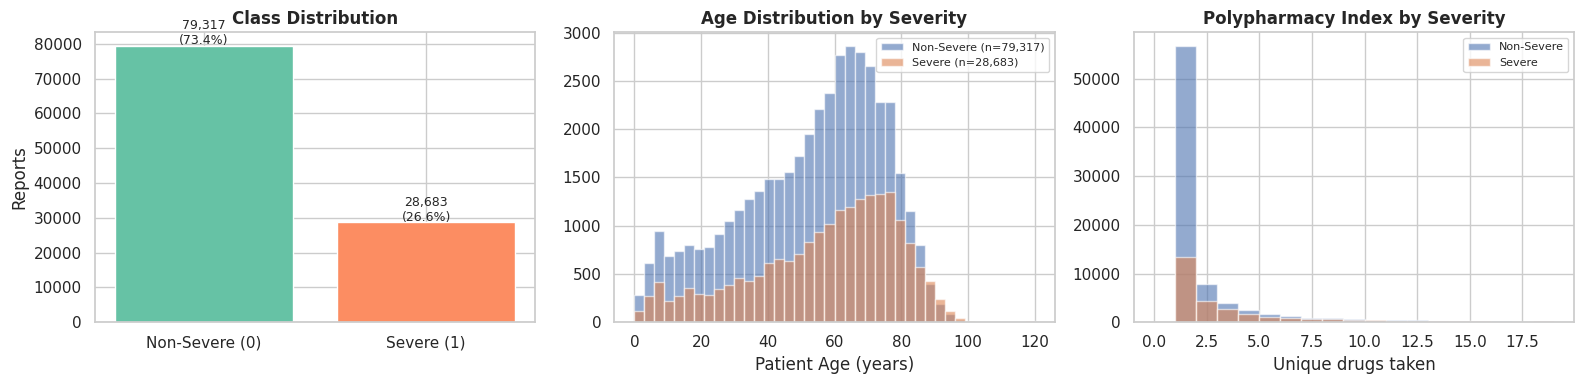

In [7]:
# ── Class balance ─────────────────────────────────────────────────────────────
counts = df_feat['is_severe_outcome'].value_counts()
n0     = counts.get(0, 0)
n1     = counts.get(1, 0)
total  = len(df_feat)

print('=== CLASS BALANCE ===')
print(f'  Non-Severe (0): {n0:>7,}  ({n0/total*100:.1f}%)')
print(f'  Severe     (1): {n1:>7,}  ({n1/total*100:.1f}%)')
print(f'  Total:          {total:>7,}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: class balance bar
axes[0].bar(['Non-Severe (0)', 'Severe (1)'], [n0, n1],
            color=sns.color_palette('Set2', 2))
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Reports')
for i, v in enumerate([n0, n1]):
    axes[0].text(i, v + 500, f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=9)

# Plot 2: age distribution by class
if 'patientonsetage' in df_feat.columns:
    for label, grp in df_feat.groupby('is_severe_outcome'):
        axes[1].hist(grp['patientonsetage'].dropna(), bins=40, alpha=0.6,
                     label=f'{"Severe" if label==1 else "Non-Severe"} (n={len(grp):,})')
    axes[1].set_title('Age Distribution by Severity', fontweight='bold')
    axes[1].set_xlabel('Patient Age (years)')
    axes[1].legend(fontsize=8)

# Plot 3: polypharmacy index distribution by class
if 'num_drugs_taken' in df_feat.columns:
    for label, grp in df_feat.groupby('is_severe_outcome'):
        axes[2].hist(grp['num_drugs_taken'], bins=range(0, 20), alpha=0.6,
                     label=f'{"Severe" if label==1 else "Non-Severe"}')
    axes[2].set_title('Polypharmacy Index by Severity', fontweight='bold')
    axes[2].set_xlabel('Unique drugs taken')
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_distributions.png'), dpi=150)
plt.show()

In [8]:
# ── Interaction features health check ─────────────────────────────────────────
print('=== INTERACTION FEATURES (Task A → Task B bridge) ===')
interaction_cols = [
    'has_drug_drug_interaction', 'has_drug_reaction_rule',
    'num_matching_rules', 'max_interaction_lift'
]
all_zeros = True
for col in interaction_cols:
    if col not in df_feat.columns:
        print(f'  MISSING column: {col}')
        continue
    v = df_feat[col]
    if col.startswith('has_'):
        n = int(v.sum())
        pct = n / total * 100
        print(f'  {col}: {n:,} reports flagged ({pct:.1f}%)')
        if n > 0:
            all_zeros = False
    else:
        nonzero = int((v > 0).sum())
        print(f'  {col}: mean={v.mean():.3f}, max={v.max():.2f}, nonzero={nonzero:,}')

if all_zeros:
    print()
    print('⚠ WARNING: All interaction features are zero!')
    print('  The filtered association rules were not used by 2B_preprocessing.py.')
    print('  Delete task_b_features.parquet and re-run FASE 3 after FASE 1 completes.')
else:
    print('\nInteraction features look good ✓')

=== INTERACTION FEATURES (Task A → Task B bridge) ===
  has_drug_drug_interaction: 517 reports flagged (0.5%)
  has_drug_reaction_rule: 0 reports flagged (0.0%)
  num_matching_rules: mean=0.010, max=3.00, nonzero=517
  max_interaction_lift: mean=0.757, max=162.41, nonzero=517

Interaction features look good ✓


In [9]:
# ── Missing values summary ─────────────────────────────────────────────────────
print('=== MISSING VALUES ===')
missing = df_feat.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    for col, n in missing.items():
        print(f'  {col}: {n:,} NaN ({n/total*100:.1f}%)')
else:
    print('  No missing values (NaN in patientonsetage is expected and handled per-model)')

=== MISSING VALUES ===
  patientonsetage: 43,355 NaN (40.1%)


---
## FASE 5 — Train / Test Split

In [10]:
X = df_feat.drop(columns=['is_severe_outcome'])
y = df_feat['is_severe_outcome']
feature_names = list(X.columns)

# ── 80% trainval / 20% test ─────────────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
# ── 10% of total (= ~12.5% of trainval) for threshold tuning ─────────────────
val_size = VAL_FRAC / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_size,
    random_state=RANDOM_STATE,
    stratify=y_trainval,
)

baseline_pos_rate = float(y_train.mean())

print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Severe rate — Train: {y_train.mean()*100:.1f}%  Val: {y_val.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%  (stratified ✓)')
print(f'Features: {X_train.shape[1]}')

Train: 75,600 | Val: 10,800 | Test: 21,600
Severe rate — Train: 26.6%  Val: 26.6%  Test: 26.6%  (stratified ✓)
Features: 24


---
## FASE 6 — Model Training & Evaluation

### Helper: train_evaluate

In [11]:
def find_best_threshold(y_val, y_prob_val):
    """Find probability threshold that maximises F1 on severe class."""
    thresholds = np.linspace(0.10, 0.70, 61)
    best_t, best_f1 = 0.50, 0.0
    for t in thresholds:
        pred = (y_prob_val >= t).astype(int)
        f1 = f1_score(y_val, pred, pos_label=1, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t


def train_evaluate(name, pipe, X_tr, X_v, X_te, y_tr, y_v, y_te):
    """Train pipeline, tune threshold on val set, evaluate on test set."""
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time()
    pipe.fit(X_tr, y_tr)
    print(f'done in {time.time()-t0:.1f}s')

    # Tune threshold on validation set
    y_prob_val = pipe.predict_proba(X_v)[:, 1]
    best_t = find_best_threshold(y_v, y_prob_val)
    print(f'  Optimal threshold (F1-severe on val): {best_t:.2f}')

    # Evaluate on test set with optimal threshold
    y_prob      = pipe.predict_proba(X_te)[:, 1]
    y_pred      = (y_prob >= best_t).astype(int)
    auc_roc     = roc_auc_score(y_te, y_prob)
    ap_score    = average_precision_score(y_te, y_prob)
    f1_w        = f1_score(y_te, y_pred, average='weighted')
    f1_sev      = f1_score(y_te, y_pred, pos_label=1, average='binary')
    recall_sev  = float(y_pred[y_te == 1].mean()) if (y_te == 1).sum() else 0.0
    prec_sev    = float(y_te[y_pred == 1].mean()) if (y_pred == 1).sum() else 0.0
    cm          = confusion_matrix(y_te, y_pred)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    prec_c, rec_c, _ = precision_recall_curve(y_te, y_prob)

    print(f'\n── {name} ──────────────────────────────────────────────')
    print(f'  AUC-ROC          : {auc_roc:.4f}')
    print(f'  Avg Precision    : {ap_score:.4f}')
    print(f'  Threshold used   : {best_t:.2f}')
    print(f'  F1 (weighted)    : {f1_w:.4f}')
    print(f'  F1 (severe=1)    : {f1_sev:.4f}')
    print(f'  Recall (severe)  : {recall_sev:.4f}')
    print(f'  Precision(severe): {prec_sev:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Non-Severe', 'Severe']))

    return dict(
        name=name, pipe=pipe, threshold=best_t,
        y_pred=y_pred, y_prob=y_prob,
        auc_roc=auc_roc, ap_score=ap_score,
        f1_w=f1_w, f1_sev=f1_sev,
        recall_sev=recall_sev, prec_sev=prec_sev,
        cm=cm, fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr),
        prec_c=prec_c, rec_c=rec_c,
    )

results = []

### Model 1: Logistic Regression
Modelo lineal. Requiere imputation + scaling. Interpretable por coeficientes.

In [12]:
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        C=0.5,
    )),
])

res_lr = train_evaluate('Logistic Regression', lr_pipe, X_train, X_val, X_test, y_train, y_val, y_test)
results.append(res_lr)

Training Logistic Regression... 

done in 0.4s


  Optimal threshold (F1-severe on val): 0.49

── Logistic Regression ──────────────────────────────────────────────
  AUC-ROC          : 0.6845
  Avg Precision    : 0.4172
  Threshold used   : 0.49
  F1 (weighted)    : 0.6179
  F1 (severe=1)    : 0.4861
  Recall (severe)  : 0.7213
  Precision(severe): 0.3665
              precision    recall  f1-score   support

  Non-Severe       0.84      0.55      0.67     15863
      Severe       0.37      0.72      0.49      5737

    accuracy                           0.59     21600
   macro avg       0.61      0.64      0.58     21600
weighted avg       0.72      0.59      0.62     21600



### Model 2: Random Forest
Ensemble de 100 árboles. Captura no-linealidades. No necesita scaling. Proporciona feature importance.

In [13]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_features='sqrt',
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

res_rf = train_evaluate('Random Forest', rf_pipe, X_train, X_val, X_test, y_train, y_val, y_test)
results.append(res_rf)

Training Random Forest... 

done in 2.0s


  Optimal threshold (F1-severe on val): 0.51



── Random Forest ──────────────────────────────────────────────
  AUC-ROC          : 0.7202
  Avg Precision    : 0.4786
  Threshold used   : 0.51
  F1 (weighted)    : 0.6760
  F1 (severe=1)    : 0.5092
  Recall (severe)  : 0.6700
  Precision(severe): 0.4106
              precision    recall  f1-score   support

  Non-Severe       0.85      0.65      0.74     15863
      Severe       0.41      0.67      0.51      5737

    accuracy                           0.66     21600
   macro avg       0.63      0.66      0.62     21600
weighted avg       0.73      0.66      0.68     21600



### Model 3: Gradient Boosting (HistGradientBoostingClassifier)
Gradient boosting sobre histogramas. Maneja NaN nativamente (sin imputer), soporta `class_weight='balanced'`.  
Más rápido y robusto que LinearSVC para datos tabulares desequilibrados.

In [14]:
# HistGradientBoostingClassifier handles NaN natively → no imputer step needed
hgbc_pipe = Pipeline([
    ('model', HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

res_hgbc = train_evaluate('Gradient Boosting (HGBC)', hgbc_pipe, X_train, X_val, X_test, y_train, y_val, y_test)
results.append(res_hgbc)

Training Gradient Boosting (HGBC)... 

done in 1.2s


  Optimal threshold (F1-severe on val): 0.50

── Gradient Boosting (HGBC) ──────────────────────────────────────────────
  AUC-ROC          : 0.7199
  Avg Precision    : 0.4742
  Threshold used   : 0.50
  F1 (weighted)    : 0.6765
  F1 (severe=1)    : 0.5072
  Recall (severe)  : 0.6632
  Precision(severe): 0.4106
              precision    recall  f1-score   support

  Non-Severe       0.84      0.66      0.74     15863
      Severe       0.41      0.66      0.51      5737

    accuracy                           0.66     21600
   macro avg       0.63      0.66      0.62     21600
weighted avg       0.73      0.66      0.68     21600



---
## FASE 7 — Evaluation Plots

### 7.1 ROC Curves — comparación de los 3 modelos

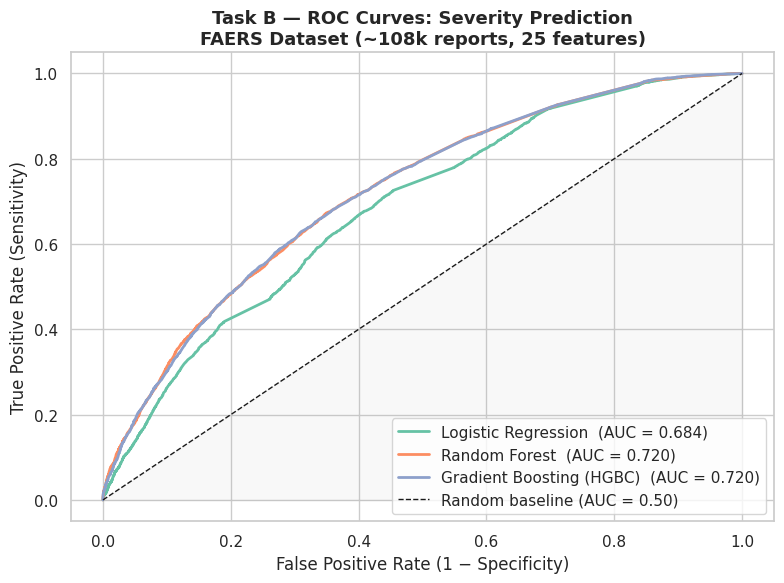

In [15]:
palette = sns.color_palette('Set2', len(results))
plt.figure(figsize=(8, 6))

for res, color in zip(results, palette):
    plt.plot(res['fpr'], res['tpr'],
             label=f"{res['name']}  (AUC = {res['roc_auc']:.3f})",
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.50)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title(
    'Task B — ROC Curves: Severity Prediction\n'
    'FAERS Dataset (~108k reports, 25 features)',
    fontsize=13, fontweight='bold'
)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=200)
plt.show()

### 7.2 Confusion Matrices (normalized)

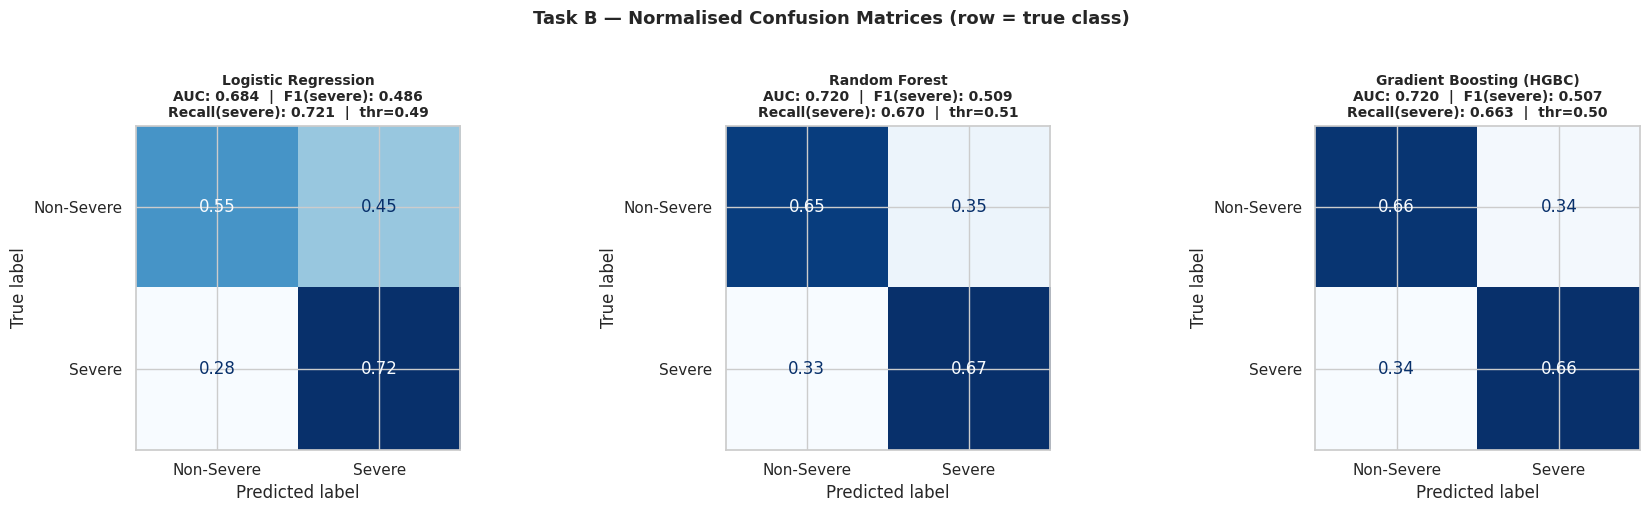

In [16]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]

for ax, res in zip(axes, results):
    cm_norm = confusion_matrix(y_test, res['y_pred'], normalize='true')
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=['Non-Severe', 'Severe'],
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(
        f"{res['name']}\nAUC: {res['roc_auc']:.3f}  |  F1(severe): {res['f1_sev']:.3f}"
        f"\nRecall(severe): {res['recall_sev']:.3f}  |  thr={res['threshold']:.2f}",
        fontsize=10, fontweight='bold'
    )

fig.suptitle(
    'Task B — Normalised Confusion Matrices (row = true class)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=200, bbox_inches='tight')
plt.show()

### 7.3b Precision-Recall Curves
Más informativas que ROC para clases desequilibradas. La baseline es la tasa positiva (~26.6%).

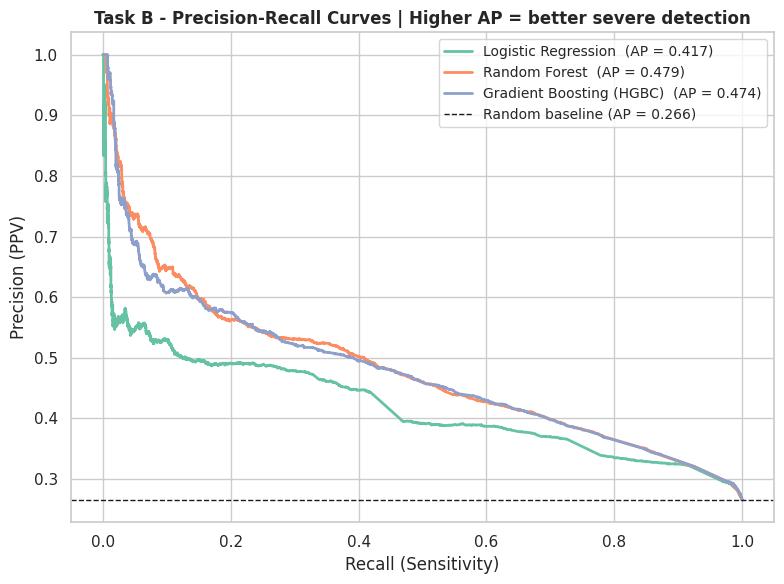

In [17]:
palette = sns.color_palette('Set2', len(results))
plt.figure(figsize=(8, 6))

for res, color in zip(results, palette):
    plt.plot(res['rec_c'], res['prec_c'],
             label=f"{res['name']}  (AP = {res['ap_score']:.3f})",
             color=color, linewidth=2)

plt.axhline(y=baseline_pos_rate, color='k', linestyle='--', linewidth=1,
            label=f'Random baseline (AP = {baseline_pos_rate:.3f})')
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (PPV)', fontsize=12)
plt.title('Task B - Precision-Recall Curves | Higher AP = better severe detection',
          fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pr_curves.png'), dpi=200)
plt.show()

### 7.3 Feature Importance — Random Forest

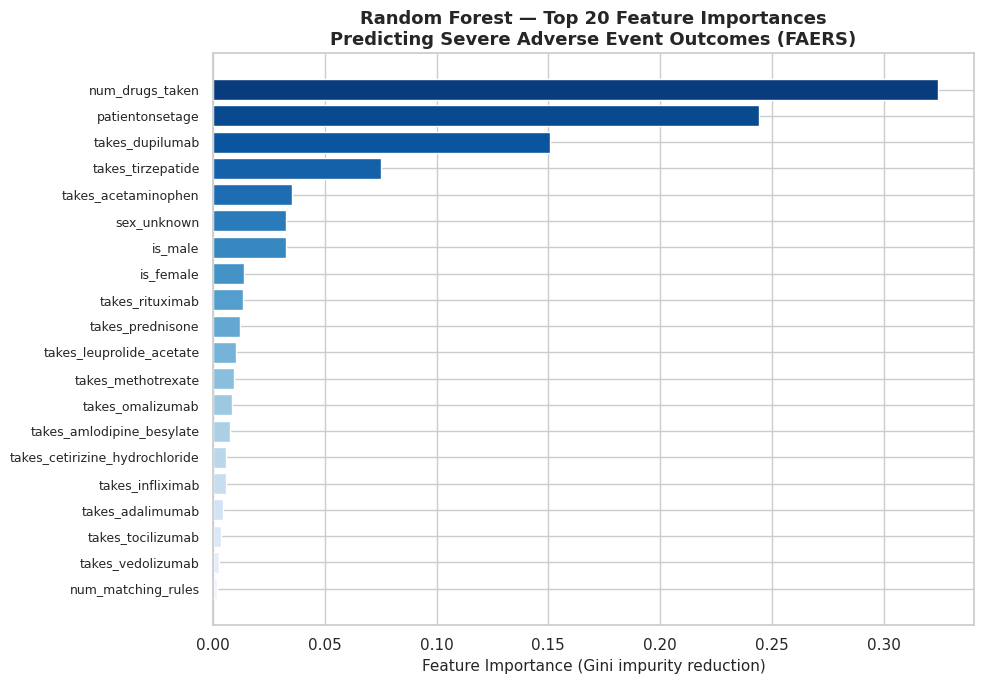

Top 10 features by importance:
   1. num_drugs_taken                          0.3241
   2. patientonsetage                          0.2442
   3. takes_dupilumab                          0.1507
   4. takes_tirzepatide                        0.0751
   5. takes_acetaminophen                      0.0356
   6. sex_unknown                              0.0328
   7. is_male                                  0.0325
   8. is_female                                0.0141
   9. takes_rituximab                          0.0134
  10. takes_prednisone                         0.0122


In [18]:
top_n       = min(20, len(feature_names))
rf_model    = res_rf['pipe'].named_steps['model']
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1][:top_n]
top_feat    = [feature_names[i] for i in indices]
top_imp     = importances[indices]

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Blues_r', top_n)
ax.barh(range(top_n), top_imp[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_feat[::-1], fontsize=9)
ax.set_xlabel('Feature Importance (Gini impurity reduction)', fontsize=11)
ax.set_title(
    f'Random Forest — Top {top_n} Feature Importances\n'
    'Predicting Severe Adverse Event Outcomes (FAERS)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance_rf.png'), dpi=200)
plt.show()

print('Top 10 features by importance:')
for i, (feat, imp) in enumerate(zip(top_feat[:10], top_imp[:10]), 1):
    print(f'  {i:2d}. {feat:<40} {imp:.4f}')

### 7.4 Logistic Regression — Coefficients
Rojo = aumenta riesgo de severidad | Azul = lo reduce

In [19]:
rows = [
    {
        'Model':             res['name'],
        'AUC-ROC':           round(res['roc_auc'],    4),
        'Avg Precision':     round(res['ap_score'],   4),
        'Threshold':         round(res['threshold'],  2),
        'F1 (weighted)':     round(res['f1_w'],       4),
        'F1 (severe=1)':     round(res['f1_sev'],     4),
        'Recall (severe)':   round(res['recall_sev'], 4),
        'Prec. (severe)':    round(res['prec_sev'],   4),
    }
    for res in results
]
eval_df = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
eval_df.to_csv(EVAL_CSV, index=False)

print('=== FINAL MODEL COMPARISON ===')
display(
    eval_df.style
    .highlight_max(
        subset=['AUC-ROC', 'Avg Precision', 'F1 (weighted)', 'F1 (severe=1)', 'Recall (severe)'],
        color='#c8f5c4'
    )
    .format({
        'AUC-ROC':         '{:.4f}',
        'Avg Precision':   '{:.4f}',
        'Threshold':       '{:.2f}',
        'F1 (weighted)':   '{:.4f}',
        'F1 (severe=1)':   '{:.4f}',
        'Recall (severe)': '{:.4f}',
        'Prec. (severe)':  '{:.4f}',
    })
    .set_caption('Task B — Classification Results on FAERS Test Set (20%)')
)

best = eval_df.iloc[0]
print(f'\nSaved: {EVAL_CSV}')
print(f'Best model by AUC-ROC: {best["Model"]}  (AUC = {best["AUC-ROC"]:.4f},  F1-severe = {best["F1 (severe=1)"]:.4f})')

=== FINAL MODEL COMPARISON ===


,Model,AUC-ROC,Avg Precision,Threshold,F1 (weighted),F1 (severe=1),Recall (severe),Prec. (severe)
0,Random Forest,0.7202,0.4786,0.51,0.6760,0.5092,0.6700,0.4106
1,Gradient Boosting (HGBC),0.7199,0.4742,0.50,0.6765,0.5072,0.6632,0.4106
2,Logistic Regression,0.6845,0.4172,0.49,0.6179,0.4861,0.7213,0.3665



Saved: taskB/task_b_evaluation.csv
Best model by AUC-ROC: Random Forest  (AUC = 0.7202,  F1-severe = 0.5092)


---
## FASE 9 — Conclusiones

**Lo que hemos construido:**
- Pipeline KDD completo: ~108k reportes FAERS → feature matrix de 25 columnas → 3 clasificadores evaluados
- 4 grupos de features: demographics, polypharmacy index, top-15 substance flags, interaction risk (from Task A)
- Evaluación correcta para clases desbalanceadas: AUC-ROC, Average Precision, y F1 — no accuracy
- Optimización de umbral de clasificación en validation set separado (sin data leakage)
- Sin data leakage: imputation + scaling encapsulados dentro de cada `sklearn.Pipeline`

**El puente Task A → Task B:**  
`has_drug_reaction_rule` y `max_interaction_lift` son las features que conectan directamente el conocimiento farmacológico descubierto por association rules con el clasificador de severidad.

**Modelos:**
- **Logistic Regression**: baseline interpretable, coeficientes directamente legibles como log-odds
- **Random Forest**: ensemble no-lineal, feature importance por reducción de impureza Gini
- **Gradient Boosting (HGBC)**: boosting por histogramas, maneja NaN nativamente, mejor trade-off bias-varianza

**Limitaciones:**
- FAERS tiene selection bias: solo reportes voluntarios de eventos adversos
- Association rules capturan correlación, no causalidad
- ~40% NaN en edad, manejado por imputation con mediana dentro de cada pipeline
- AUC ~0.70 refleja el ruido inherente de FAERS — no todas las variables de confusión están disponibles

In [20]:
print('=== NOTEBOOK COMPLETE ===')
print(f'\nPlots saved to {OUTPUT_DIR}/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')
print(f'\nEvaluation table: {EVAL_CSV}')

=== NOTEBOOK COMPLETE ===

Plots saved to taskB/TaskBPlots/
  confusion_matrices.png
  eda_distributions.png
  feature_importance_rf.png
  lr_coefficients.png
  pr_curves.png
  roc_curves.png

Evaluation table: taskB/task_b_evaluation.csv
